<a href="https://colab.research.google.com/github/IrineuACgasoso/decision-tree-cin0142/blob/main/projeto2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROJETO 02 | Manutenção Preditiva Industrial — Análise Estatística e Engenharia de Dados**
## **Universidade Federal de Pernambuco (UFPE)**
### **Centro de Informática (CIn)**


---

#### **Grupo de Desenvolvimento e Autores:**
> Caio Amarante Calderaro `<cac>`

> Felipe Almeida Albuquerque de Holanda `<faah>`

> Guilherme Galindo Zloccowick `<ggz>`

> Guilherme Laurentino Santos `<gls8>`

> Heitor Nascimento Briano `<hnb>`

> Kaynan Roberth Torres Silva `<krts>`

> Maria Clara Pereira Gonçalves `<mcpg>`

#### **Contexto do Projeto:**
* **Disciplina:** CIN0142 Estatística e Probabilidade para Computação
* **Professor(a):** Renata Maria Cardoso Rodrigues de Souza
* **Data de Entrega:** 31 de Maio de 2026





---


##**Seção 1 - Introdução**

### **1.1 Contextualização**
A manutenção preditiva é uma estratégia utilizada na indústria para prever possíveis falhas em máquinas e equipamentos antes que elas aconteçam. Essa abordagem utiliza dados coletados por sensores e sistemas de monitoramento para identificar padrões que indiquem desgaste ou risco de falha.

Sua importância está relacionada à redução de custos com manutenção corretiva, diminuição do tempo de parada das máquinas e aumento da eficiência operacional. O dataset utilizado neste projeto representa informações de funcionamento de máquinas industriais, contendo variáveis relacionadas ao desempenho, temperatura, desgaste e falhas dos equipamentos.

### **1.2 Objetivo**
*É possível prever se uma máquina irá falhar com base nas suas condições operacionais?*

O objetivo deste projeto é analisar os dados de manutenção preditiva e identificar padrões associados às falhas das máquinas. Busca-se compreender quais variáveis possuem maior relação com a ocorrência de falhas e como essas informações podem auxiliar na prevenção de problemas industriais.

### **1.3 Descrição dos Dados**

O dataset utilizado contém informações sobre o funcionamento de máquinas industriais utilizadas em um ambiente de produção. Os dados incluem variáveis operacionais, condições de temperatura, velocidade de rotação e indicadores de falha.

### Fonte dos Dados

O conjunto de dados foi obtido de uma base pública voltada para estudos de manutenção preditiva e análise de falhas em equipamentos industriais.

Referência: S. Matzka, "Explainable Artificial Intelligence for Predictive Maintenance Applications," AI4I 2020.

### Dicionário das Variáveis

| Coluna | Descrição |
|---|---|
| UDI | Identificador único de cada registro |
| Product ID | Identificação do produto ou máquina |
| Type | Tipo de máquina ou categoria do equipamento |
| Air temperature [K] | Temperatura do ar em Kelvin |
| Process temperature [K] | Temperatura do processo em Kelvin |
| Rotational speed [rpm] | Velocidade de rotação em rotações por minuto |
| Torque [Nm] | Torque aplicado na máquina em Newton-metro |
| Tool wear [min] | Tempo de desgaste da ferramenta em minutos |
| Machine failure | Indica se ocorreu falha geral na máquina |
| TWF | Falha por desgaste da ferramenta |
| HDF | Falha por dissipação de calor |
| PWF | Falha por potência |
| OSF | Falha por sobrecarga |
| RNF | Falha aleatória |





---


## **Seção 2 — Análise Exploratória de Dados (Univariada)**




<a name="bloco-limpeza"></a>

### **2.1 Carregamento e Limpeza dos Dados**

In [2]:
url <- "https://raw.githubusercontent.com/IrineuACgasoso/Projeto-2-Estatistica/refs/heads/main/ai4i2020.csv"

install.packages("ggplot2")
library(ggplot2)

# TEMA DOS GRÁFICOS
theme_machine <- function() {

  theme_minimal() +

    theme(

      # Fundo
      plot.background = element_rect(
        fill = "#1E1E1E",
        color = NA
      ),

      panel.background = element_rect(
        fill = "#1E1E1E",
        color = NA
      ),

      # Grades
      panel.grid.major = element_line(
        color = "#3A3A3A",
        linewidth = 0.3
      ),

      panel.grid.minor = element_blank(),

      # Título
      plot.title = element_text(
        hjust = 0.5,
        size = 18,
        face = "bold",
        color = "#EAEAEA"
      ),

      # Eixos
      axis.title = element_text(
        size = 13,
        face = "bold",
        color = "#EAEAEA"
      ),

      axis.text = element_text(
        size = 11,
        color = "#EAEAEA"
      ),

      # Legenda
      legend.title = element_text(
        color = "#EAEAEA"
      ),

      legend.text = element_text(
        color = "#EAEAEA"
      ),

      legend.background = element_rect(
        fill = "#1E1E1E",
        color = NA
      ),

      # Fundo da legenda
      legend.key = element_rect(
        fill = "#1E1E1E",
        color = NA
      )
    )
}


df <- read.csv(url)

str(df)

summary(df)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



'data.frame':	10000 obs. of  14 variables:
 $ UDI                    : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Product.ID             : chr  "M14860" "L47181" "L47182" "L47183" ...
 $ Type                   : chr  "M" "L" "L" "L" ...
 $ Air.temperature..K.    : num  298 298 298 298 298 ...
 $ Process.temperature..K.: num  309 309 308 309 309 ...
 $ Rotational.speed..rpm. : int  1551 1408 1498 1433 1408 1425 1558 1527 1667 1741 ...
 $ Torque..Nm.            : num  42.8 46.3 49.4 39.5 40 41.9 42.4 40.2 28.6 28 ...
 $ Tool.wear..min.        : int  0 3 5 7 9 11 14 16 18 21 ...
 $ Machine.failure        : int  0 0 0 0 0 0 0 0 0 0 ...
 $ TWF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ HDF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ PWF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ OSF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ RNF                    : int  0 0 0 0 0 0 0 0 0 0 ...


      UDI            Product.ID           Type       Air.temperature..K.
 Min.   :    1   Length   :10000   Length   :10000   Min.   :295.3      
 1st Qu.: 2501   N.unique :10000   N.unique :    3   1st Qu.:298.3      
 Median : 5000   N.blank  :    0   N.blank  :    0   Median :300.1      
 Mean   : 5000   Min.nchar:    6   Min.nchar:    1   Mean   :300.0      
 3rd Qu.: 7500   Max.nchar:    6   Max.nchar:    1   3rd Qu.:301.5      
 Max.   :10000                                       Max.   :304.5      
 Process.temperature..K. Rotational.speed..rpm.  Torque..Nm.    Tool.wear..min.
 Min.   :305.7           Min.   :1168           Min.   : 3.80   Min.   :  0    
 1st Qu.:308.8           1st Qu.:1423           1st Qu.:33.20   1st Qu.: 53    
 Median :310.1           Median :1503           Median :40.10   Median :108    
 Mean   :310.0           Mean   :1539           Mean   :39.99   Mean   :108    
 3rd Qu.:311.1           3rd Qu.:1612           3rd Qu.:46.80   3rd Qu.:162    
 Max.   :

In [3]:

sum(is.na(df))

[1] 0

Nota-se que o dataset não possui valores nulos, o que facilitou o processo de limpeza.

In [4]:
sum(duplicated(df))

[1] 0

Também não havia células duplicadas.

In [5]:
df$Type <- as.factor(df$Type)
df$Machine.failure <- as.factor(df$Machine.failure)
str(df)

'data.frame':	10000 obs. of  14 variables:
 $ UDI                    : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Product.ID             : chr  "M14860" "L47181" "L47182" "L47183" ...
 $ Type                   : Factor w/ 3 levels "H","L","M": 3 2 2 2 2 3 2 2 3 3 ...
 $ Air.temperature..K.    : num  298 298 298 298 298 ...
 $ Process.temperature..K.: num  309 309 308 309 309 ...
 $ Rotational.speed..rpm. : int  1551 1408 1498 1433 1408 1425 1558 1527 1667 1741 ...
 $ Torque..Nm.            : num  42.8 46.3 49.4 39.5 40 41.9 42.4 40.2 28.6 28 ...
 $ Tool.wear..min.        : int  0 3 5 7 9 11 14 16 18 21 ...
 $ Machine.failure        : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 1 1 1 ...
 $ TWF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ HDF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ PWF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ OSF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ RNF                    : int  0 0 0 0 0 0 0 0 0 0 ...


Transformamos as colunas "*Type*" e "*Machine.failure*" em fatores para distinguir suas variáveis categóricas das demais variáveis numéricas.

<a name="bloco-analise-univariada"></a>

### **2.2 Análise Univariada**


####**2.2.1 Machine Failure**

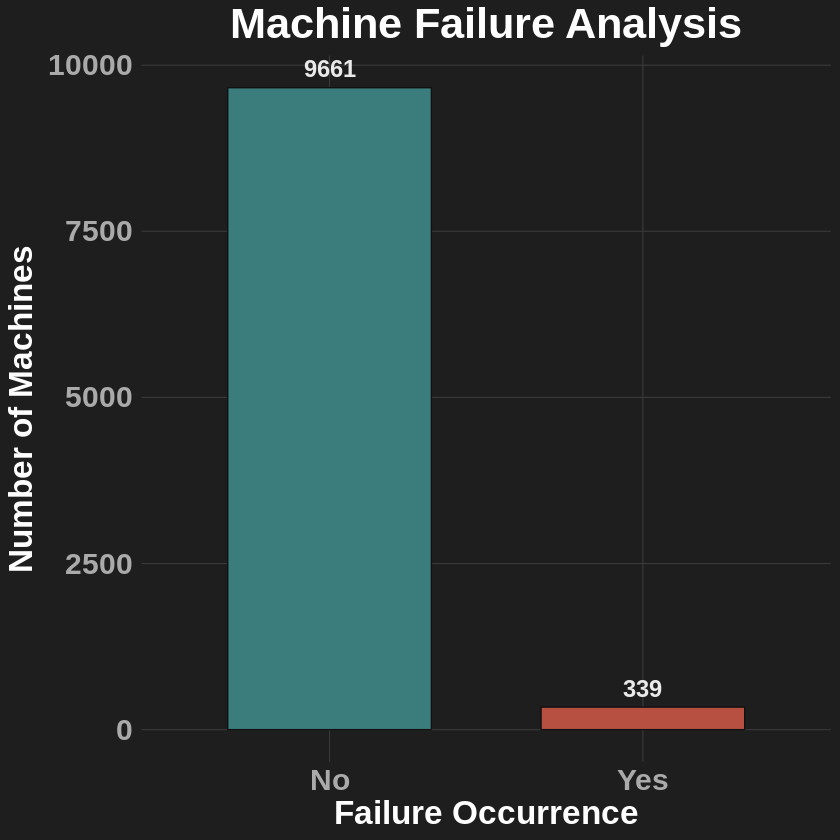

In [6]:
ggplot(data = df, aes(x = Machine.failure, fill = Machine.failure)) +

  geom_bar(
    width = 0.65,
    color = "#111111",
    linewidth = 0.4
  ) +

  geom_text(
    stat = "count",
    aes(label = after_stat(count)),
    vjust = -0.6,
    size = 5,
    fontface = "bold",
    color = "#EAEAEA"
  ) +

  labs(
    title = "Machine Failure Analysis",
    x = "Failure Occurrence",
    y = "Number of Machines"
  ) +

  scale_x_discrete(
    labels = c(
      "0" = "No",
      "1" = "Yes"
    )
  ) +

  scale_fill_manual(
    values = c(
      "0" = "#3A7D7C",
      "1" = "#B85042"
    )
  ) +

  theme_machine() +

theme(
    legend.position = "none",
    axis.text = element_text(color = "#aaaaaa", size = 18, face = "bold"), # Letras dos eixos grandes e grossas
    axis.title = element_text(size = 20, face = "bold", color = "white"), # Títulos dos eixos
    plot.title = element_text(hjust = 0.5, size = 26, face = "bold", color = "white") # Título principal grande
)

A avaliação da variável alvo revela um cenário de **severo desbalanceamento de classes**, um comportamento típico e desafiador em problemas de manutenção preditiva.

* **Volumetria dos Dados:** * Total de observações: **10.000 registros**
  * Eventos de falha ($1$): **339 ocorrências**
  * Taxa de prevalência: **3,39%**
* **Impacto Operacional:** O conjunto de dados é amplamente dominado pela classe majoritária (operação normal).
* **Impacto no Modelo (Árvore de Decisão):** Há uma tendência estatística de **viesar o treinamento**.
  * O algoritmo pode ser induzido a ignorar a classe minoritária (as falhas) para otimizar a acurácia global, gerando previsões excessivamente otimistas (falsos negativos).

####**2.2.2 Tool Wear**

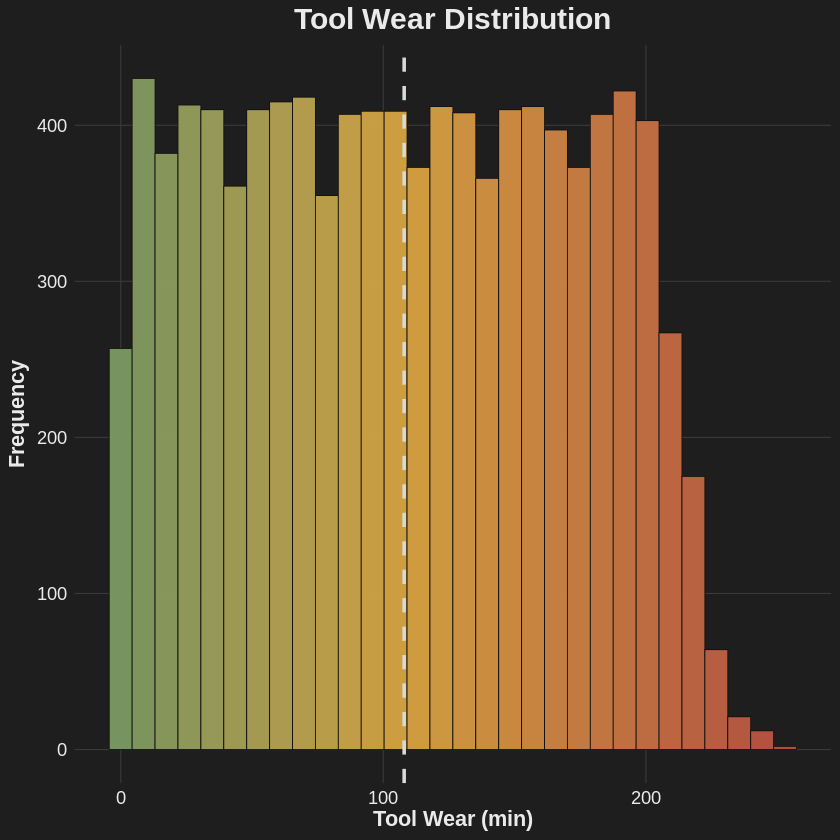

In [7]:
ggplot(data = df, aes(x = Tool.wear..min., fill = after_stat(x))) +

  geom_histogram(
    bins = 30,
    alpha = 0.95,
    color = "#111111",
    linewidth = 0.25
  ) +

  labs(
    title = "Tool Wear Distribution",
    x = "Tool Wear (min)",
    y = "Frequency"
  ) +

  scale_fill_gradient2(
    low = "#4C956C",
    mid = "#D9A441",
    high = "#B85042",
    midpoint = mean(df$Tool.wear..min.)
  ) +

  geom_vline(
    aes(xintercept = mean(Tool.wear..min.)),
    color = "#D9D9D9",
    linetype = "dashed",
    linewidth = 1
  ) +

  theme_machine() +

  theme(
    legend.position = "none"
  )

In [8]:
# Cálculos das métricas
media  <- mean(df$Tool.wear..min.)
mediana <- median(df$Tool.wear..min.)
desvio_padrao <- sd(df$Tool.wear..min.)
minimo <- min(df$Tool.wear..min.)
maximo <- max(df$Tool.wear..min.)

# Cálculo da Moda (seu código original)
moda <- as.numeric(
  names(sort(table(df$Tool.wear..min.), decreasing = TRUE)[1])
)

# Criação da tabela atualizada e robusta
tabela <- data.frame(
  Estatisticas = c("Mínimo", "Máximo", "Média", "Mediana", "Moda", "Desvio Padrão"),
  Valor = c(
    round(minimo, 1),
    round(maximo, 1),
    round(media, 1),
    round(mediana, 1),
    round(moda, 1),
    round(desvio_padrao, 1)
  )
)
colnames(tabela) <- c("Estatísticas", "Valor")

# Exibição
print(as.data.frame(tabela), row.names = FALSE)

  Estatísticas Valor
        Mínimo   0.0
        Máximo 253.0
         Média 108.0
       Mediana 108.0
          Moda   0.0
 Desvio Padrão  63.7


Os resultados estatísticos do desgaste da ferramenta revelam um comportamento de **Distribuição Uniforme**, característico de processos de ciclo de vida controlado:

* **Simetria Quase Perfeita:** A proximidade extrema entre a Média (**108,0 min**) e a Mediana (**107,5 min**) confirma que os dados estão distribuídos de maneira homogênea ao longo de toda a escala operacional (de 0 a 253 minutos).
* **Alta Dispersão ($DP = 63,7$ min):** O desvio padrão elevado reflete o fato de que o dataset captura máquinas em todos os estágios possíveis de operação — desde ferramentas novas até aquelas prestes a falhar por desgaste.
* **O Fenômeno da Moda (0 min):** O valor zero se destaca como a moda devido ao reset do contador de desgaste. Toda vez que uma ferramenta atinge sua vida útil máxima ou sofre uma falha, ela é substituída por uma nova, reiniciando o ciclo em 0 minutos.

####**2.2.3 Torque (Nm)**

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



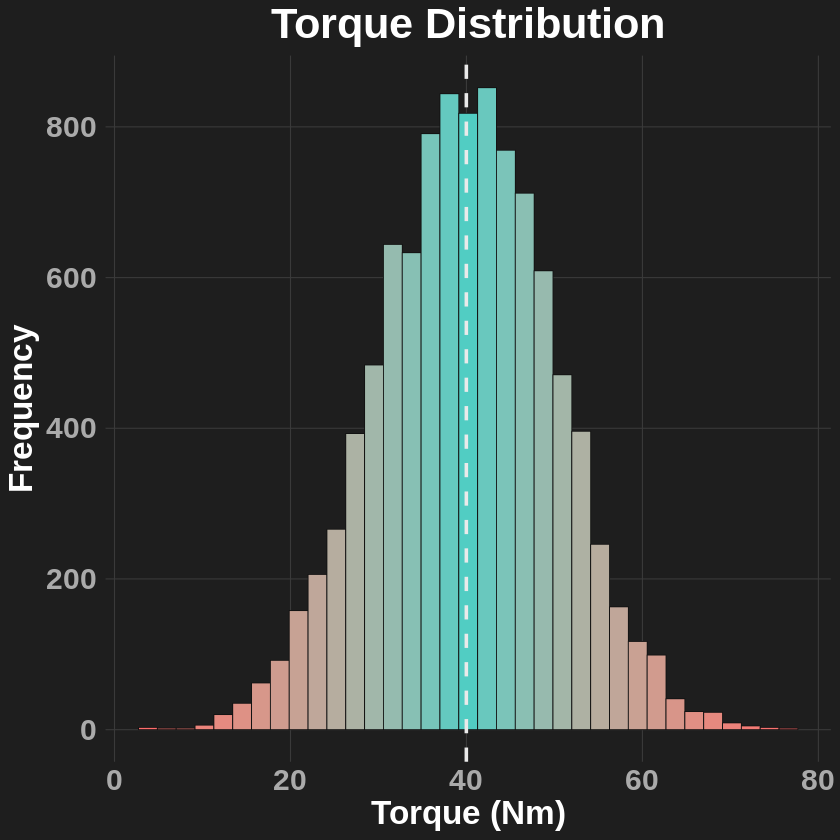

In [9]:
ggplot(
  data = df,
  aes(
    x = Torque..Nm.,
    fill = after_stat(x)
  )
) +

  geom_histogram(
    bins = 35,
    color = "#111111",
    linewidth = 0.25
  ) +

  labs(
    title = "Torque Distribution",
    x = "Torque (Nm)",
    y = "Frequency"
  ) +

  scale_fill_gradient2(
    low = "#FF6B6B",
    mid = "#4ECDC4",
    high = "#FF6B6B",
    midpoint = mean(df$Torque..Nm.)
  ) +

  geom_vline(
    aes(xintercept = mean(Torque..Nm.)),
    color = "#EAEAEA",
    linetype = "dashed",
    linewidth = 1
  ) +

  theme_machine() +

  theme(
    legend.position = "none",
    axis.text = element_text(color = "#aaaaaa", size = 18, face = "bold"), # Letras dos eixos grandes e grossas
    axis.title = element_text(size = 20, face = "bold", color = "white"), # Títulos dos eixos
    plot.title = element_text(hjust = 0.5, size = 26, face = "bold", color = "white") # Título principal grande
)

install.packages("svglite")

ggsave("grafico_torque.png",
       width = 8,           # Aumentamos a largura da base
       height = 8,          # Aumentamos a altura
       units = "in",
       dpi = 600,           # DOBRAMOS a resolução padrão de impressão (vai para 600 DPI)
       bg = "#121212")      # Força o fundo a ir totalmente escuro sem bordas brancas

In [10]:
# Cálculos das métricas
media  <- mean(df$Torque..Nm.)
mediana <- median(df$Torque..Nm.)
desvio_padrao <- sd(df$Torque..Nm.)
minimo <- min(df$Torque..Nm.)
maximo <- max(df$Torque..Nm.)

# Cálculo da Moda (seu código original)
moda <- as.numeric(
  names(sort(table(df$Torque..Nm.), decreasing = TRUE)[1])
)

# Criação da tabela atualizada e robusta
tabela <- data.frame(
  Estatisticas = c("Mínimo", "Máximo", "Média", "Mediana", "Moda", "Desvio Padrão"),
  Valor = c(
    round(minimo, 1),
    round(maximo, 1),
    round(media, 1),
    round(mediana, 1),
    round(moda, 1),
    round(desvio_padrao, 1)
  )
)
colnames(tabela) <- c("Estatísticas", "Valor")

# Exibição
print(as.data.frame(tabela), row.names = FALSE)

  Estatísticas Valor
        Mínimo   3.8
        Máximo  76.6
         Média  40.0
       Mediana  40.1
          Moda  40.2
 Desvio Padrão  10.0


A análise univariada do Torque revela um comportamento clássico de **Distribuição Normal Simétrica**, caracterizado por um regime de operação altamente estável:

* **Simetria Central Perfeita:** A extrema proximidade entre a Média (**40,0 Nm**), a Mediana (**40,1 Nm**) e a Moda (**40,2 Nm**) fornece a contraprova estatística de que os dados se espalham de forma perfeitamente equilibrada em torno do ponto central. O fato de a moda estar colada na média comprova que a zona de maior frequência do gráfico é, de fato, o centro estável.
* **Comportamento das Caudas (Limites Operacionais):** A rápida queda na frequência à medida que nos afastamos do centro demonstra que operações em condições críticas ou extremas — próximas ao mínimo de **3,8 Nm** ou ao máximo de **76,6 Nm** — são raras na rotina da fábrica.
* **Dispersão Controlada ($DP = 10,0$ Nm):** O desvio padrão cravado em 10,0 Nm indica que a maior parte do tempo de operação (~68% dos dados, seguindo a regra empírica da distribuição normal) ocorre de forma previsível na faixa segura de **30,0 Nm a 50,0 Nm**.

####**2.2.4 Rotacional Speed (rpm)**

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



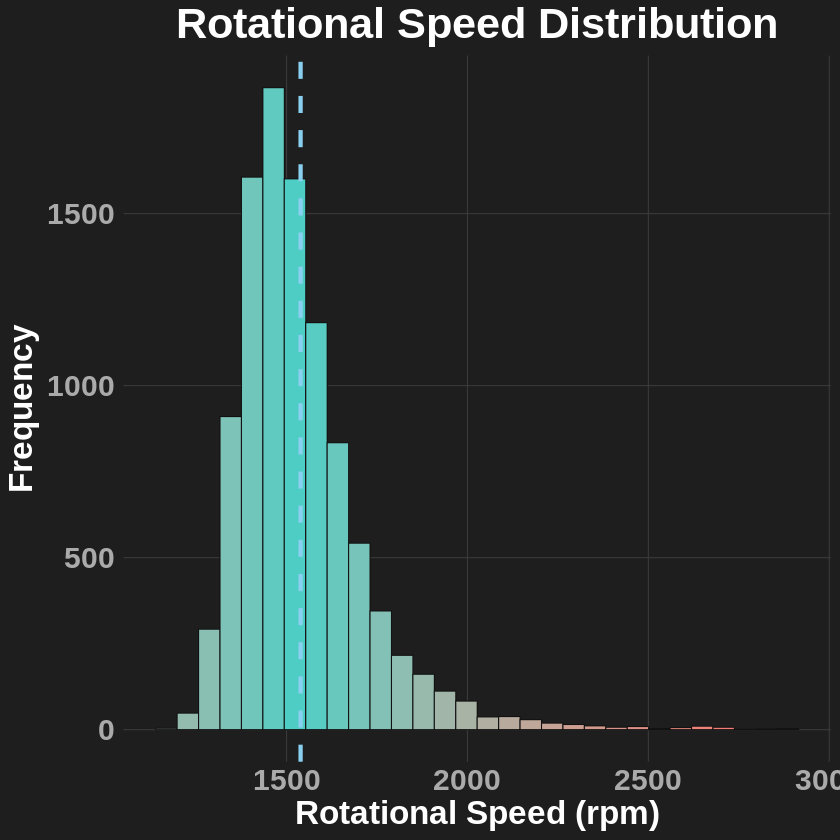

In [11]:
ggplot(
  data = df,
  aes(
    x = Rotational.speed..rpm.,
    fill = abs(after_stat(x) - mean(df$Rotational.speed..rpm.))
  )
) +

  geom_histogram(
    bins = 30,
    color = "#111111",
    linewidth = 0.3
  ) +

  labs(
    title = "Rotational Speed Distribution",
    x = "Rotational Speed (rpm)",
    y = "Frequency"
  ) +

  scale_fill_gradient(
    low = "#4ECDC4",
    high = "#FF6B6B"
  ) +

  geom_vline(
    aes(xintercept = mean(Rotational.speed..rpm.)),
    color = "#89CFF0",
    linetype = "dashed",
    linewidth = 1.2
  ) +

  theme_machine() +

  theme(
    legend.position = "none",
    axis.text = element_text(color = "#aaaaaa", size = 18, face = "bold"), # Letras dos eixos grandes e grossas
    axis.title = element_text(size = 20, face = "bold", color = "white"), # Títulos dos eixos
    plot.title = element_text(hjust = 0.5, size = 26, face = "bold", color = "white") # Título principal grande
)

A distribuição da velocidade rotacional apresenta maior concentração em valores intermediários (próximos a 1.500 rpm), decaindo rapidamente para valores baixos, mas estendendo-se em uma cauda longa para valores muito elevados. Isso sugere que, embora a maior parte das máquinas opere em faixas moderadas de rotação, existe um regime importante de operações sob altas velocidades.

####**2.2.5 Air Temperature (°K)**

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



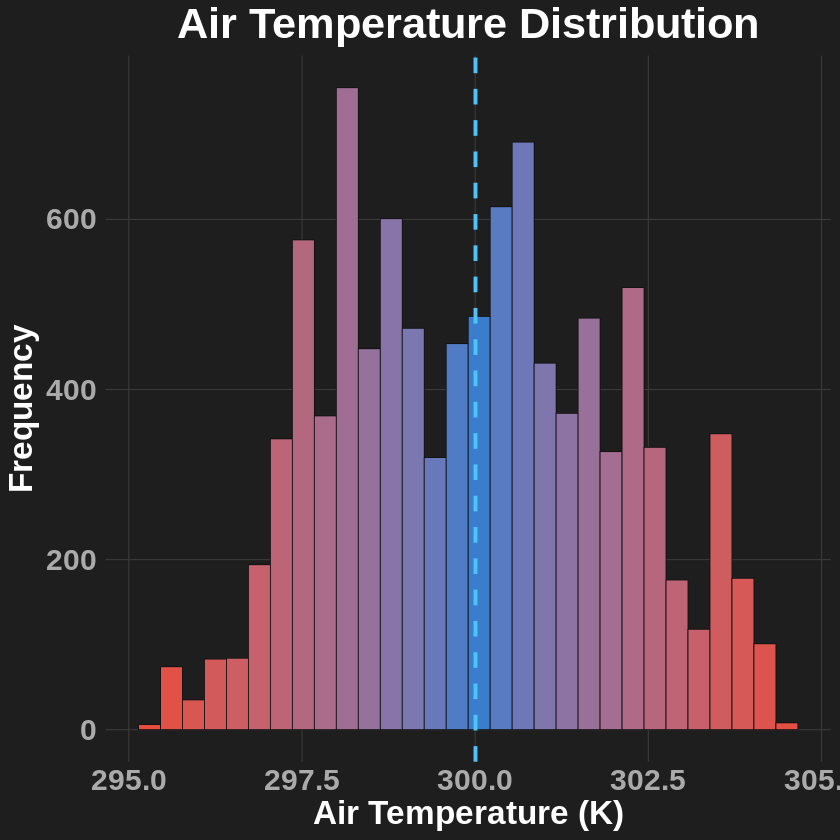

In [37]:
ggplot(
  data = df,
  aes(
    x = Air.temperature..K.,
    fill = abs(after_stat(x) - mean(df$Air.temperature..K.))
  )
) +

  geom_histogram(
    bins = 30,
    color = "#111111",
    linewidth = 0.25
  ) +

  labs(
    title = "Air Temperature Distribution",
    x = "Air Temperature (K)",
    y = "Frequency"
  ) +

  scale_fill_gradient(
    low = "#3A7DCC",
    high = "#E74C3C"
  ) +

  geom_vline(
    aes(xintercept = mean(Air.temperature..K.)),
    color = "#4FC3F7",
    linetype = "dashed",
    linewidth = 1.1
  ) +

  theme_machine() +

  theme(
      legend.position = "none",
      axis.text = element_text(color = "#aaaaaa", size = 18, face = "bold"), # Letras dos eixos grandes e grossas
      axis.title = element_text(size = 20, face = "bold", color = "white"), # Títulos dos eixos
      plot.title = element_text(hjust = 0.5, size = 26, face = "bold", color = "white") # Título principal grande
  )

  install.packages("svglite")

  ggsave("grafico_air_temp.png",
       width = 8,           # Aumentamos a largura da base
       height = 8,          # Aumentamos a altura
       units = "in",
       dpi = 600,           # DOBRAMOS a resolução padrão de impressão (vai para 600 DPI)
       bg = "#121212")      # Força o fundo a ir totalmente escuro sem bordas brancas

In [38]:
# Cálculos das métricas
media  <- mean(df$Air.temperature..K.)
mediana <- median(df$Air.temperature..K.)
desvio_padrao <- sd(df$Air.temperature..K.)
minimo <- min(df$Air.temperature..K.)
maximo <- max(df$Air.temperature..K.)

# Cálculo da Moda (seu código original)
moda <- as.numeric(
  names(sort(table(df$Air.temperature..K.), decreasing = TRUE)[1])
)

# Criação da tabela atualizada e robusta
tabela <- data.frame(
  Estatisticas = c("Mínimo", "Máximo", "Média", "Mediana", "Moda", "Desvio Padrão"),
  Valor = c(
    round(minimo, 1),
    round(maximo, 1),
    round(media, 1),
    round(mediana, 1),
    round(moda, 1),
    round(desvio_padrao, 1)
  )
)
colnames(tabela) <- c("Estatísticas", "Valor")

# Exibição
print(as.data.frame(tabela), row.names = FALSE)

  Estatísticas Valor
        Mínimo 295.3
        Máximo 304.5
         Média 300.0
       Mediana 300.1
          Moda 300.7
 Desvio Padrão   2.0


A distribuição da temperatura do ar apresenta uma forma simétrica (normal) com forte concentração em torno da sua média (300 K), indicando baixa variabilidade nas condições ambientais de operação das máquinas e a ausência de extremos térmicos.

####**2.2.6 Process Temperature**

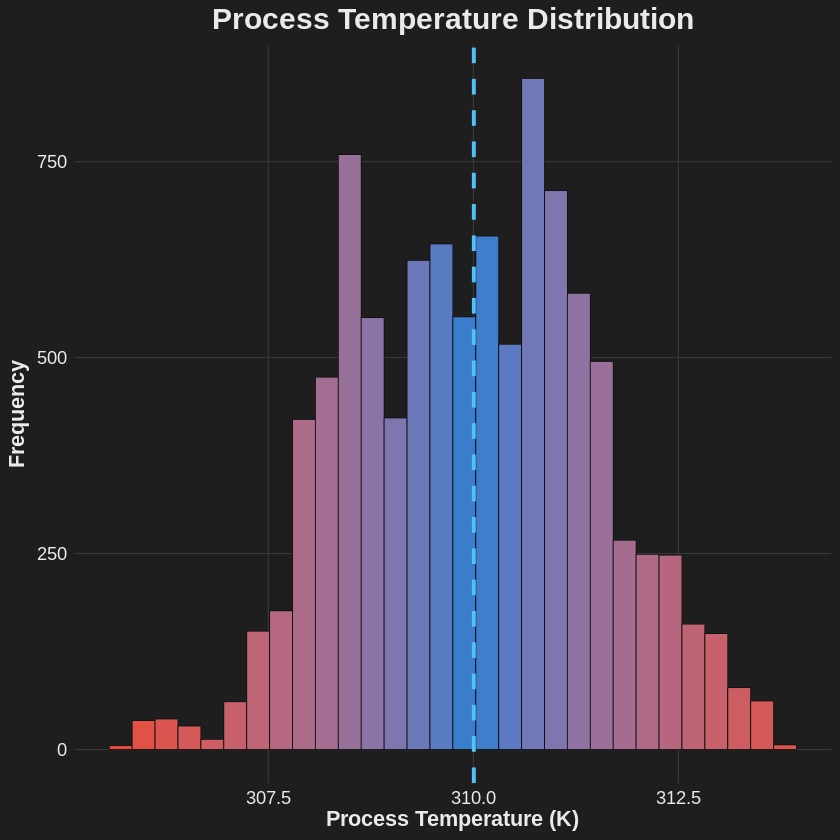

In [13]:
ggplot(
  data = df,
  aes(
    x = Process.temperature..K.,
    fill = abs(after_stat(x) - mean(df$Process.temperature..K.))
  )
) +

  geom_histogram(
    bins = 30,
    color = "#111111",
    linewidth = 0.25
  ) +

  labs(
    title = "Process Temperature Distribution",
    x = "Process Temperature (K)",
    y = "Frequency"
  ) +

  scale_fill_gradient(
    low = "#3A7DCC",
    high = "#E74C3C"
  ) +

  geom_vline(
    aes(xintercept = mean(Process.temperature..K.)),
    color = "#4FC3F7",
    linetype = "dashed",
    linewidth = 1.1
  ) +

  theme_machine() +

  theme(
    legend.position = "none"
  )

O histograma obtido revela um comportamento que se alinha ao modelo teórico de uma **Distribuição Normal Simétrica**. Diferente de outras variáveis do sistema, esta distribuição apresenta uma assimetria praticamente nula ($\text{skewness} \approx 0,01$), resultando em um formato de sino visualmente limpo e bem definido. Essa estabilidade nos valores indica que há um rigoroso controle de temperatura, no qual extremos são raros e podem indicar possíveis falhas.

<a name="bloco-analise-bivariada"></a>
### **2.3 Análise Bivariada**

####**2.3.1 Relação entre Torque e Velocidade Rotacional (Scatter Plot)**

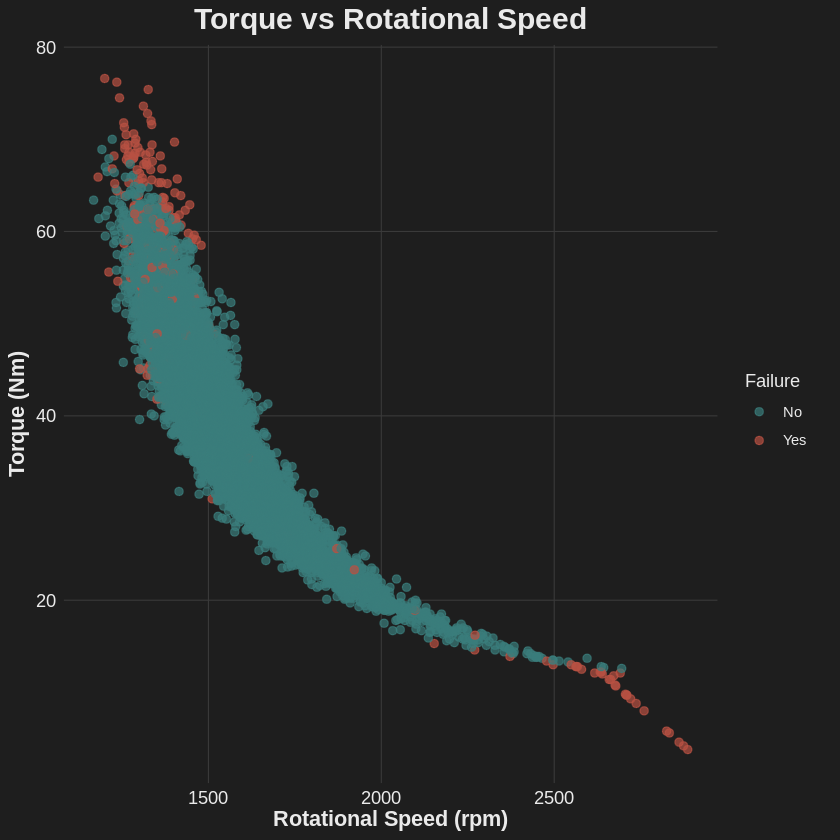

In [14]:
ggplot(
  data = df,
  aes(x = Rotational.speed..rpm., y = Torque..Nm., color = Machine.failure)
) +
  geom_point(alpha = 0.7, size = 2) +
  labs(
    title = "Torque vs Rotational Speed",
    x = "Rotational Speed (rpm)",
    y = "Torque (Nm)",
    color = "Failure"
  ) +
  scale_color_manual(
    values = c("0" = "#3A7D7C", "1" = "#B85042"),
    labels = c("No", "Yes")
  ) +
  theme_machine() +
  theme(
    legend.position = "right"
  )

O gráfico de dispersão revela uma forte correlação negativa não-linear entre o Torque e a Velocidade Rotacional, formando uma fronteira hiperbólica característica do limite de potência das máquinas ($Potência = Torque \times Velocidade$). Observa-se que a grande maioria das falhas (pontos em vermelho) aglomera-se nas extremidades desse espectro: ou em cenários de altíssimo torque e baixa rotação (sobrecarga mecânica), ou em altíssima rotação com baixo torque. Esta relação bivariada isola de forma muito clara as zonas de risco operacional.

####**2.3.2 Desgaste da Ferramenta e Ocorrência de Falhas (Boxplot)**

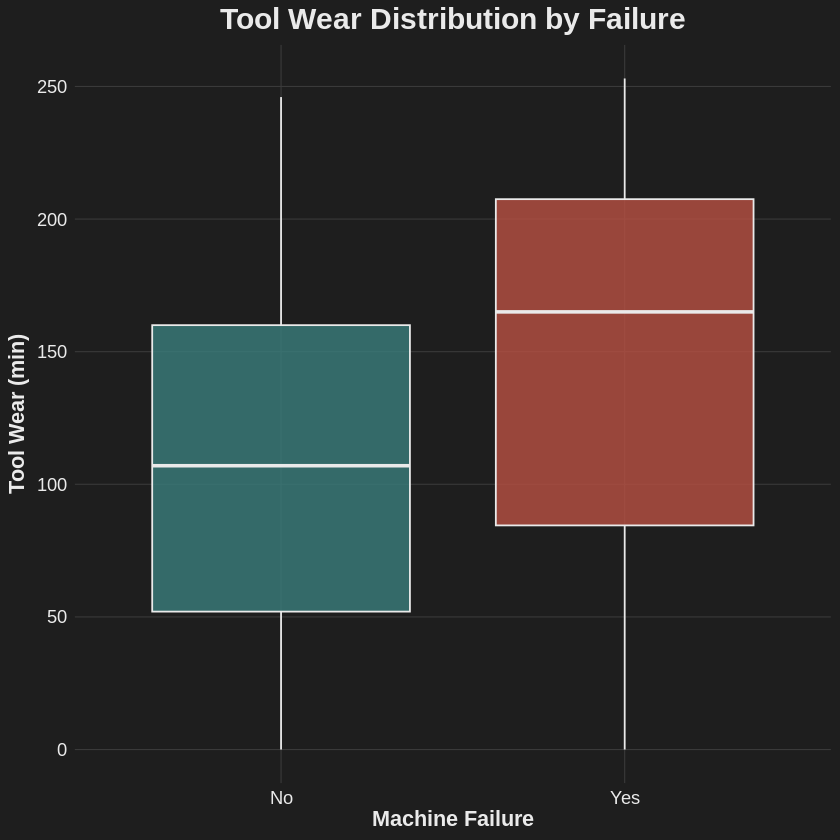

In [15]:
ggplot(
  data = df,
  aes(x = Machine.failure, y = Tool.wear..min., fill = Machine.failure)
) +
  geom_boxplot(
    alpha = 0.8,
    color = "#EAEAEA",
    outlier.color = "#B85042",
    outlier.size = 2
  ) +
  labs(
    title = "Tool Wear Distribution by Failure",
    x = "Machine Failure",
    y = "Tool Wear (min)"
  ) +
  scale_x_discrete(
    labels = c("0" = "No", "1" = "Yes")
  ) +
  scale_fill_manual(
    values = c("0" = "#3A7D7C", "1" = "#B85042")
  ) +
  theme_machine() +
  theme(
    legend.position = "none"
  )

O boxplot evidencia que a mediana do tempo de desgaste da ferramenta (Tool wear) é significativamente maior nos casos onde houve falha (classe 1). Enquanto as máquinas que não falharam operam em uma faixa ampla (mediana próxima a 100 minutos), as máquinas que registraram falhas concentram-se fortemente acima dos 150 minutos de desgaste. Isso confirma a intuição da análise univariada de que o tempo prolongado de uso da ferramenta é um forte catalisador de quebras.

####**2.3.3 Matriz de Correlação (Heatmap)**

In [16]:
install.packages(c("reshape2", "knitr"))
library(reshape2)
library(knitr)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘plyr’




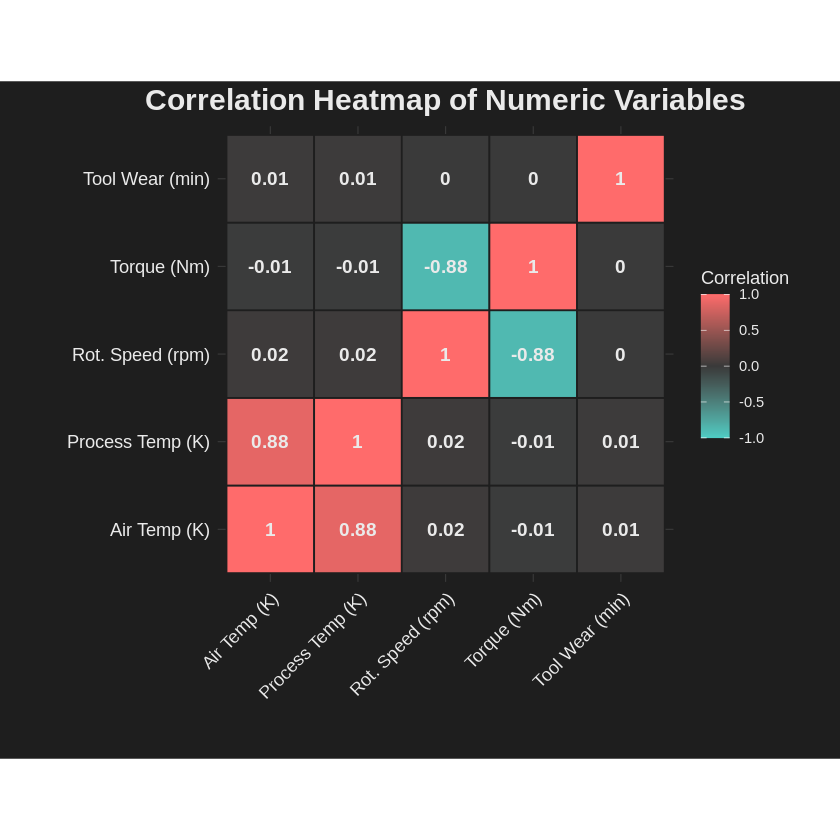

In [17]:
# Seleção de variáveis (apenas numéricas)
df_num <- df[, c("Air.temperature..K.", "Process.temperature..K.",
                 "Rotational.speed..rpm.", "Torque..Nm.", "Tool.wear..min.")]
colnames(df_num) <- c("Air Temp (K)", "Process Temp (K)", "Rot. Speed (rpm)", "Torque (Nm)", "Tool Wear (min)")

# Calculo da matriz
cor_matrix <- cor(df_num)
cor_melted <- melt(cor_matrix)

# Heatmap de Correlação
ggplot(data = cor_melted, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile(color = "#1E1E1E", linewidth = 0.5) +
  scale_fill_gradient2(
    low = "#4ECDC4",
    high = "#FF6B6B",
    mid = "#3A3A3A",
    midpoint = 0,
    limit = c(-1,1),
    name = "Correlation"
  ) +
  geom_text(aes(label = round(value, 2)), color = "#EAEAEA", size = 4, fontface = "bold") +
  labs(
    title = "Correlation Heatmap of Numeric Variables",
    x = "",
    y = ""
  ) +
  coord_fixed() +
  theme_machine() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

O Heatmap confirma matematicamente os padrões visuais observados anteriormente. Destacam-se duas correlações fortíssimas:

1) Torque e Rotational Speed (-0.88): Uma correlação inversamente proporcional quase perfeita, comprovando a relação mecânica de potência.

2) Air Temperature e Process Temperature (0.88): Fortemente correlacionadas positivamente, indicando que a temperatura do processo sobe quase que proporcionalmente com a temperatura ambiente do maquinário. O Tool wear, por sua vez, não apresenta correlação linear direta com as outras variáveis operacionais, atuando de forma independente no modelo.

In [18]:
# Tabela Bivariada
tabela_medias <- aggregate(
  cbind(Air.temperature..K., Process.temperature..K., Rotational.speed..rpm., Torque..Nm., Tool.wear..min.) ~ Machine.failure,
  data = df,
  FUN = function(x) round(mean(x), 1)
)
colnames(tabela_medias) <- c("Failure (0=No, 1=Yes)", "Air Temp (K)", "Process Temp (K)", "Rot. Speed (rpm)", "Torque (Nm)", "Tool Wear (min)")

kable(tabela_medias, align = "c", caption = "Média das Variáveis Operacionais por Status de Falha")



Table: Média das Variáveis Operacionais por Status de Falha

| Failure (0=No, 1=Yes) | Air Temp (K) | Process Temp (K) | Rot. Speed (rpm) | Torque (Nm) | Tool Wear (min) |
|:---------------------:|:------------:|:----------------:|:----------------:|:-----------:|:---------------:|
|           0           |    300.0     |      310.0       |      1540.3      |    39.6     |      106.7      |
|           1           |    300.9     |      310.3       |      1496.5      |    50.2     |      143.8      |

### **2.4 Insights da EDA**

####**2.4.1 Resumo da Fase e Validação das Hipóteses**
A Análise Exploratória validou nossa hipótese inicial: é estatisticamente viável prever falhas com base nas condições operacionais. As falhas não ocorrem de maneira puramente aleatória; elas estão ancoradas em comportamentos físicos claros do equipamento. Descobrimos que a ocorrência de defeitos está ligada a "zonas de estresse" — limites extremos de torque versus velocidade ou tempos excessivos de desgaste da ferramenta.

####**2.4.2 Novas Perguntas Surgidas**
A constatação do severo desbalanceamento de classes (apenas 3,4% de falhas) na Seção 2.2 levanta o principal desafio para a próxima fase: Como o modelo de Machine Learning vai lidar com essa disparidade? Precisaremos aplicar técnicas de balanceamento (como SMOTE ou undersampling) ou ajustar os pesos das classes para evitar um modelo que apenas preveja o cenário de "não falha". Além disso, a forte correlação entre temperatura do ar e do processo sugere uma nova dúvida: Seria mais eficiente criar uma nova variável representando a "Diferença de Temperatura" em vez de usar as duas de forma isolada?

####**2.4.3 Variáveis Promissoras para a Modelagem**
Para o treinamento do modelo preditivo, as variáveis mais promissoras identificadas foram:

- Torque e Rotational Speed: A interação conjunta entre elas é o maior preditor de sobrecarga operacional.

- Tool wear: Tem grande relevância para prever quebras relacionadas à fadiga do material a partir da marca de 150-200 minutos.

- Process / Air Temperature: Promissoras, especialmente se combinadas, para detectar falhas de dissipação de calor (HDF).

<a name="bloco-validacao-estatistica"></a>



---


## **Seção 3 - Validação Estatística (Teste de Hipóteses)**




### 3.1. Definição das Hipóteses

Com base nos padrões identificados na nossa Análise Exploratória de Dados (EDA), percebemos que as quebras dos equipamentos por fadiga do material (Tool Wear) parecem ocorrer com maior frequência após a marca de 150-200 minutos de uso.

Para modelar matematicamente este comportamento, definimos primeiramente as médias de interesse:
* $\mu_{0}$: Tempo médio populacional de desgaste da ferramenta nas máquinas que operaram normalmente.
* $\mu_{1}$: Tempo médio populacional de desgaste da ferramenta nas máquinas que apresentaram falha.

Considerando que a EDA sugeriu que o desgaste é superior nos casos de avaria, formulamos um **Teste Unilateral à Direita** com as seguintes hipóteses:

* **Hipótese Nula ($H_0$):** $\mu_{1} \le \mu_{0}$
    * O tempo médio de desgaste da ferramenta nas máquinas que falharam é igual ou inferior ao das máquinas normais. Isso significa que o desgaste acumulado não tem um efeito real na ocorrência de falhas.
* **Hipótese Alternativa ($H_1$):** $\mu_{1} > \mu_{0}$
    * O tempo médio de desgaste da ferramenta é significativamente maior nos equipamentos que apresentaram falha, confirmando o desgaste como um fator crítico para a quebra.

### 3.2. Escolha a execução do teste
O teste escolhido deve contemplar as peculiaridades do dataset, especialmente considerando o comportamento das amostras em relação ao histograma do atributo Tool Wear - o qual baseia a hipótese definida.

Com isso, é possível estabelecer as propriedades que determinaram a escolha do teste:
* Análise de apenas uma variável.
* Problema de classificação binário.
* Desbalanceamento severo do dataset (96,6% amostras normais e 3,4% amostras de falha).
* Distribuição predominantemente uniforme do atributo Tool Wear.

Essas características filtram os testes que mais se adequam ao cenário e permitem que dois principais possam ser utilizados:
* Teste Mann-Whitney U.
* Teste de Permutação.

Embora o Teste de Permutação tenha um funcionamento simples, com o cálculo da média de vários subconjuntos da amostra para comparar se a média das duas classes é distinta o bastante, não foi escolhido pelo outro método se adequar mais às preferências do grupo.

O Teste de Mann-Whitney U foi definido para a análise deste cenário. Este teste é uma alternativa quando os requisitos do T Student não são cumpridos, nesse caso, os dados não seguem uma distribuição aproximadamente normal. Os dados cumprem os requisitos do Teste de Mann-Whitney U, sendo eles:
* Independência das classes (uma instância independe dos valores de outra).
* O tipo de atributo de Tool Wear é contínuo (medição de tempo), ou seja, pode ser ordenado.
* As medianas - como pode ser observado no boxplot do Tool Wear - são nitidamente diferentes, o que permite uma análise coerente sobre isso.

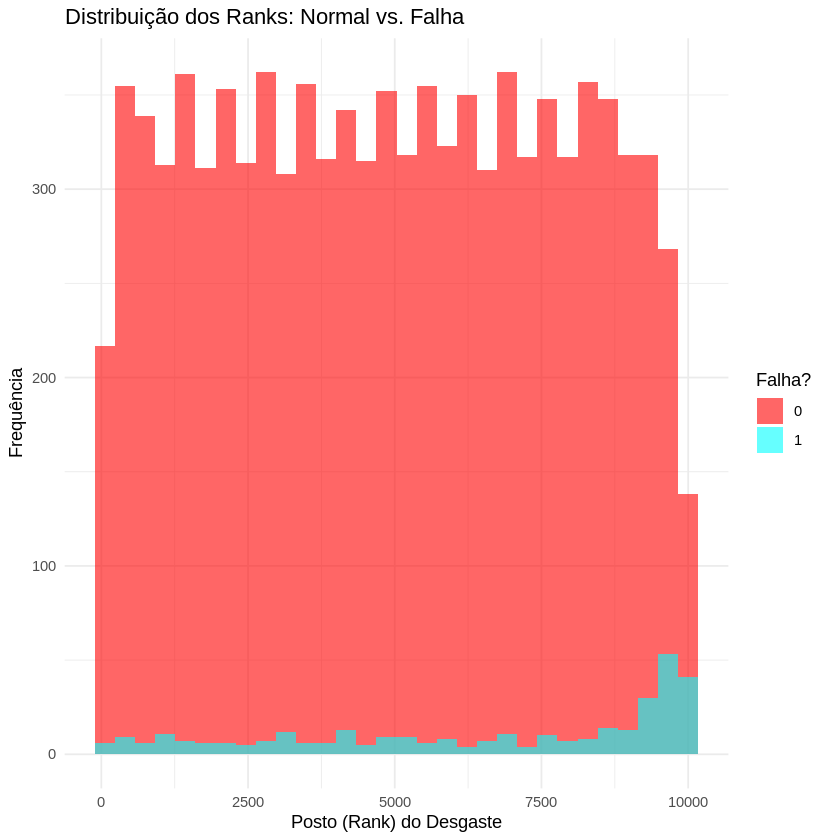

In [19]:
# Cálculo dos ranks
df$Rank_Desgaste <- rank(df$Tool.wear..min.)

# Plot do histograma
library(ggplot2)

ggplot(df, aes(x = Rank_Desgaste, fill = Machine.failure)) +
  geom_histogram(bins = 30, alpha = 0.6, position = "identity") +
  scale_fill_manual(values = c("0" = "#FF0000", "1" = "#00FFFF")) + # Corrected factor levels to "0" and "1"
  labs(title = "Distribuição dos Ranks: Normal vs. Falha",
       x = "Posto (Rank) do Desgaste",
       y = "Frequência",
       fill = "Falha?") +
  theme_minimal()

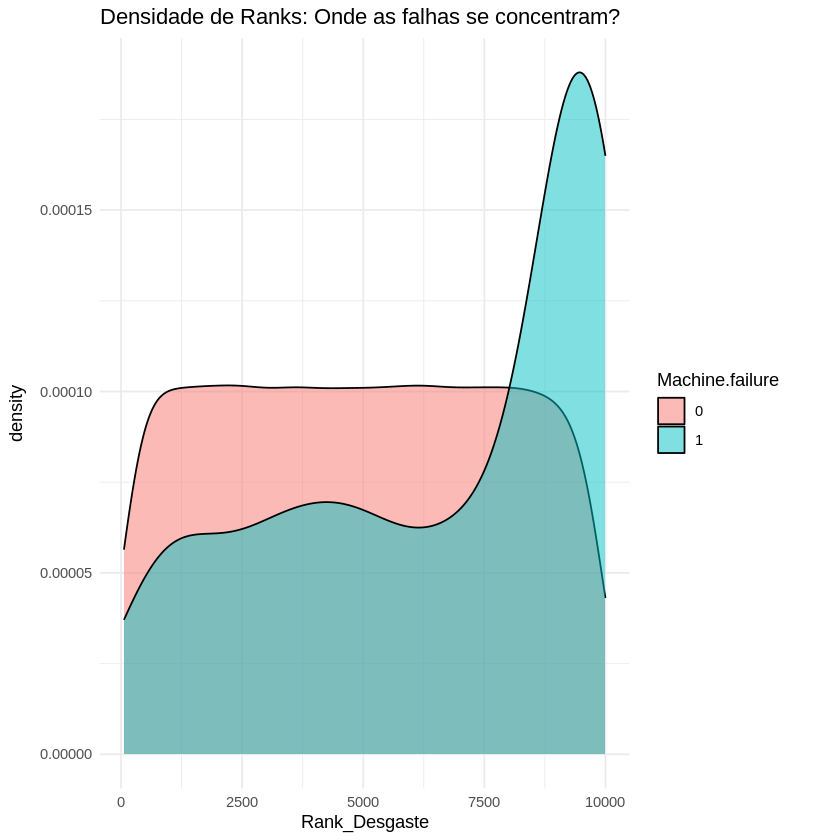

In [20]:
# Plot do histograma normalizado
ggplot(df, aes(x = Rank_Desgaste, fill = Machine.failure)) +
  geom_density(alpha = 0.5) +
  labs(title = "Densidade de Ranks: Onde as falhas se concentram?") +
  theme_minimal()

O teste Mann-Whitney é aplicado com a geração de ranks ordenados de forma crescente. Os gráficos são a visualização desses ranks após a organização e após a normalização, respectivamente. Tal representação evidencia como os valores de tempo de desgaste da classe falha se deslocam para a direita, enquanto as instâncias normais assumem distribuição quase uniforme. Vale ressaltar que é possível ocorrer falhas a qualquer instante, mas elas se concentram conforme os valores aumentam.

### 3.3. Interpretação do p-valor: Com base em um nível de significância

In [21]:
# Calcula a mediana de Tool_Wear para cada categoria de Machine_Failure
medianas <- aggregate(Tool.wear..min. ~ Machine.failure, data = df, FUN = median)
print(medianas)

  Machine.failure Tool.wear..min.
1               0             107
2               1             165


In [22]:
# Conversão do formato do atributo
df$Machine.failure <- as.factor(df$Machine.failure)

In [23]:
# Execução do teste de Mann-Whitney U
# O intervalo de confiança também é calculado
resultado_teste <- wilcox.test(Tool.wear..min. ~ Machine.failure,
                               data = df,
                               conf.int = TRUE)

# Visualizar o resultado
print(resultado_teste)


	Wilcoxon rank sum test with continuity correction

data:  Tool.wear..min. by Machine.failure
W = 1106611, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0
95 percent confidence interval:
 -47.99992 -32.00004
sample estimates:
difference in location 
             -39.99992 



* Avaliação:

A partir do código, é possível identificar que o p-valor é pequeno nesse cenário, já que o dataset é "grande", com 10.000 instâncias, e a diferença de valores entre as classes é significativa. Isso significa que é improvável que essa distinção seja por acaso.

Logo, como o teste verificou que p-valor = 2.2e-16, então p-valor < 0,05. É possível rejeitar a hipótese nula com 95% de confiança.

Tal resultado comprova que é possível distinguir a classe normal da classe falha, além de ser embasado pelo valor da mediana de cada classe, sendo a normal 107 e a falha 165 em relação ao Tool Wear. No código, essa informação é extraída de *true location shift is not equal to 0*, ou seja, há diferença significativa entre os resultados obtidos.

* Sobre o funcionamento do Teste de Mann-Whitney:

Esse método organiza as instâncias de forma crescente e rotula cada uma delas como Posto 1, Posto 2, em diante. Depois, são somados todos os postos da classe Normal e todos os postos da classe Falha. Então é comparado o quão distantes são esses valores e, como é notável pela diferença de mediana, revela que o tempo de desgaste é um forte atributo distintivo. O valor W calculado é a soma de todos os postos (ambas classes).

<a name="bloco-pre-processamento"></a>



---


## **Seção 4 — Pré-processamento e Aplicação da Técnica**




### **4.1 Preparação dos Dados para o Modelo**

Como medidas necessárias para preparar os dados antes da aplicação no modelo de Árvore de Decisão, é ncecessário transformá-los a fim de promover as seguintes características na distribuição do *dataset*:
> **`✅ OK` | Tratamento dos valores faltantes nos padrões**
<br> --> Não havia instâncias com valores faltantes no dataset ([Seção 2.1](#bloco-limpeza))

> **`✅ OK` | Encoder para uniformizar os dados categóricos no tipo *FACTOR* no R**
<br> --> Atributos `Type` e `Machine.failure` transformados no tipo *FACTOR* ([Seção 2.1](#bloco-limpeza))

> **`⬜ PENDENTE` | Balanceamento das classes para o treinamento da Árvore**
<br> --> O equilíbrio na representação de cada classe (falha e normalidade) está, evidentemente, desbalanceado e precisa ser ajustado ([Seção 2.2.1](#bloco-analise-univariada))

> **`⬜ PENDENTE` | Remoção de Colunas de Identificadores (UDI e Product.ID)**
<br> --> Essas são variáveis de alta cardinalidade que não possuem relação causal com o fenômeno físico que é o objetivo da predição. Mantê-las induziria o modelo ao overfitting (memorização dos dados de treino), pois geraria ramificações com base em cada padrão específico.

> **`⬜ PENDENTE` | Remoção de Subcausas de Falha (TWF, HDF, PWF, OSF, RNF)** <br> --> Esse passo do pré-processamento precisa a contecer para evitar Data Leakage (Vazamento de Dados), dado o *dataset* trabalhado. No contexto do danco de dados selecionado, essas colunas revelam o resultado do diagnóstico antes do modelo avaliar os sensores, o que tornaria o modelo artificialmente perfeito no treino, mas completamente inútil em um cenário real de fábrica onde apenas os sensores físicos estão disponíveis em tempo real.

<br>

Portanto, duas etapas essenciais (Tratamento de nulos e Encoder) do pré-processamento de dados prévio à implementação do modelo foram realizadas em seções anteriores para permitir a Análise Exploratória dos Dados (EDAs).
Uma vez que Árvores de Decisão lidam normalmente com atributos em escalas distintas e desproporcionais — não normalizados —, o foco desta etapa, para garantir o funcionamento ótimo do modelo preditivo, concentra-se na seleção de features para não incluir colunas de variáveis que provocam overfitting, além do ajuste do desbalanceamento entre as classes de falha ($1$) e de normalidade ($0$) unicamente na partição de TREINO e não na de TESTE.

#### **4.1.1 Divisão inicial TREINO / TESTE**

In [24]:
# Definição prévia do conjunto de TREINO e de TESTE para não gerar data leakage modificando coisas no conjunto de teste
# 1 - Seed padrão de aleatoriedade
set.seed(42)

# 2 - Divisão Treino e Teste
tamanho_treino <- floor(0.80 * nrow(df))                             # separação de 80% do conjunto balanceado
indices_treino <- sample(seq_len(nrow(df)), size = tamanho_treino)   # armazenamento dos respectivos índices pra acesso

dados_treino <- df[indices_treino, ]               # definição do dataframe de treino apenas com os dados de treinamento
dados_teste  <- df[-indices_treino, ]              # definição do dataframe de teste com os complementares dos que foram pro treino

#### **4.1.2 Feature Selection**

In [25]:
# fazemos aqui apenas a descrição e definição do conjunto de colunas que PRECISAM ser removidas
cols_a_remover <- c("UDI", "Product.ID", "TWF", "HDF", "PWF", "OSF", "RNF")

In [26]:
# 3 - Limpando o conjunto que será fornecido ao modelo
dados_treino_limpos <- dados_treino[, !(names(dados_treino) %in% cols_a_remover)] # a Árvore não recebe, no TREINO, as colunas que tendem a causar overfitting
dados_teste_limpos  <- dados_teste[, !(names(dados_teste) %in% cols_a_remover)]   # a Árvore não recebe, no TESTE, as colunas que tendem a causar overfitting

- Sobre a seleção de atributos

Com a remoção das features de identificação das máquinas ("UDI" e "Product.ID") e de tipos de falhas ocorridas ("TWF", "HDF", "PWF", "OSF", "RNF") em ambos os conjuntos, previne-se a ocorrência de um comportamento decorado do modelo, uma vez que são atributos que tornam os dados extremamente específicos e/ou atuam como "trapaças" para o algoritmo perceber que houve falha ou não, já que não terá acesso a elas no dia a dia do problema real.

#### **4.1.3 Balanceamento de Classes**

In [27]:
# Checagem do desbalanceamento de classes
tabela_freq <- table(df$Machine.failure)
tabela_prop <- prop.table(tabela_freq) * 100

tabela_final <- cbind(Quantidade = tabela_freq, `Proporção (%)` = tabela_prop)

rownames(tabela_final) <- c("0 - Sem Falha (Normalidade)", "1 - Com Falha (Anomalia)") # descrição das linhas
knitr::kable(tabela_final, digits = 2)



|                            | Quantidade| Proporção (%)|
|:---------------------------|----------:|-------------:|
|0 - Sem Falha (Normalidade) |       9661|         96.61|
|1 - Com Falha (Anomalia)    |        339|          3.39|

In [28]:
# Aplicação de balanceamento de classes para o treino da árvore
if(!require(ROSE)) install.packages("ROSE")
library(ROSE)

# Aplicando a técnica combinada de over/under sampling APENAS no treino
df_treino_balanced <- ovun.sample(Machine.failure ~ ., data = dados_treino_limpos, method = "both", p = 0.5, seed = 42)$data
df_teste <- dados_teste_limpos

# Verificando a nova distribuição numérica do TREINO (que foi balanceado para não provocar tendências)
table(df_treino_balanced$Machine.failure)

# Verificando a nova distribuição numérica do TESTE (que não foi balanceado para refletir o padrão do problema real)
table(df_teste$Machine.failure)

Loading required package: ROSE

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘ROSE’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loaded ROSE 0.0-4





   0    1 
3993 4007 


   0    1 
1919   81 

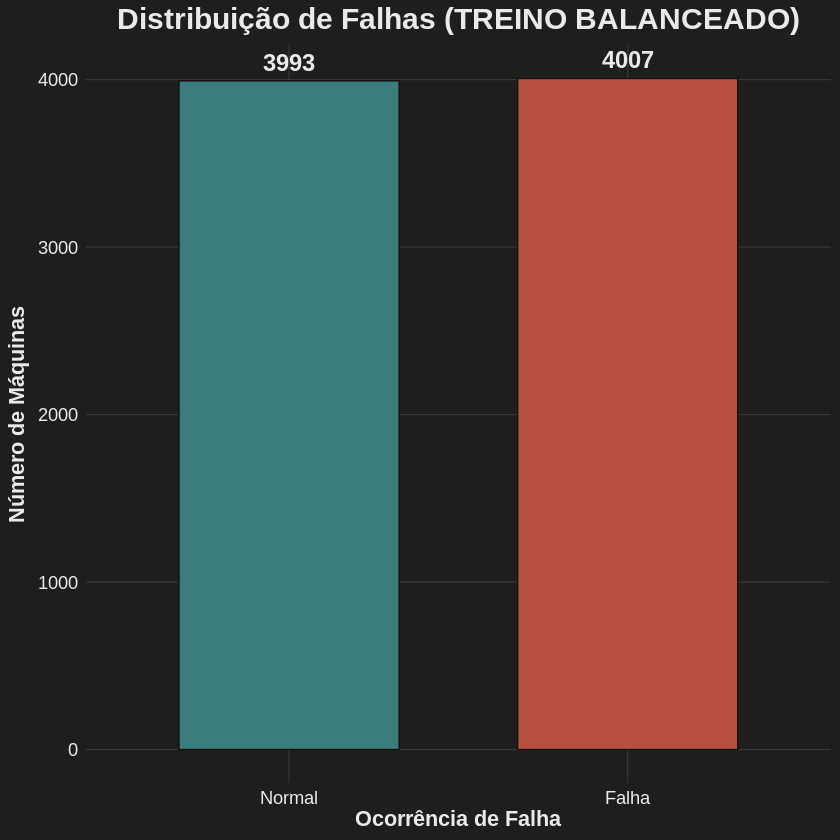

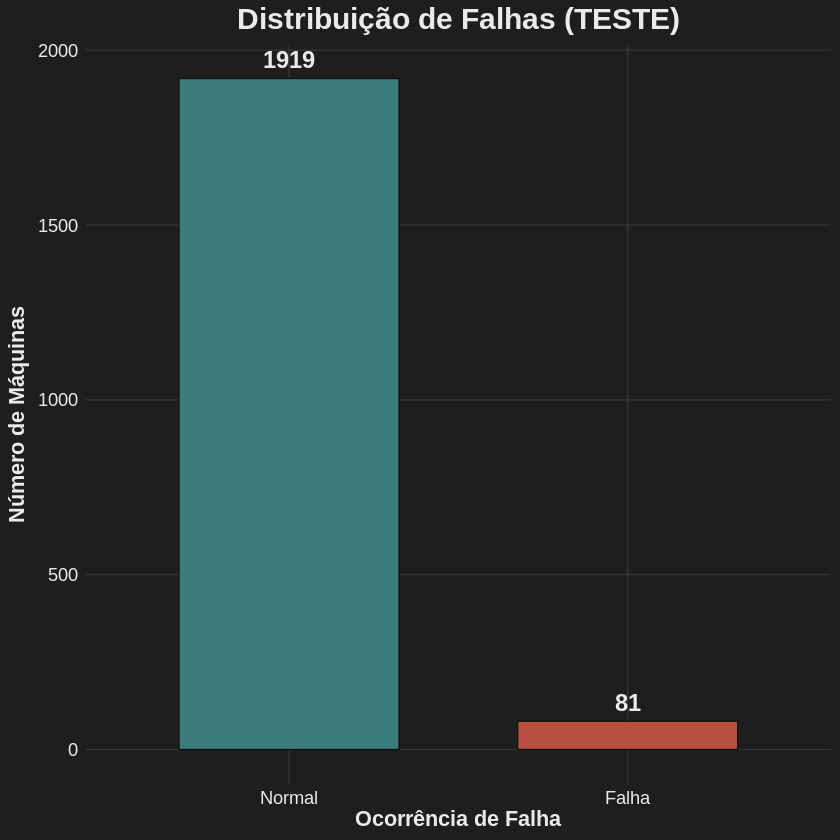

In [29]:
# Verificação no Gráfico de Barras (categórico)
ggplot(data = df_treino_balanced, aes(x = Machine.failure, fill = Machine.failure)) +
  geom_bar(
    width = 0.65,
    color = "#111111",
    linewidth = 0.4
  ) +
  geom_text(
    stat = "count",
    aes(label = after_stat(count)),
    vjust = -0.6,
    size = 5,
    fontface = "bold",
    color = "#EAEAEA"
  ) +
  labs(
    title = "Distribuição de Falhas (TREINO BALANCEADO)",
    x = "Ocorrência de Falha",
    y = "Número de Máquinas"
  ) +
  scale_x_discrete(labels = c("0" = "Normal", "1" = "Falha")) +
  scale_fill_manual(values = c("0" = "#3A7D7C", "1" = "#B85042")) +
  theme_machine() +
  theme(legend.position = "none")

# Verificação no Gráfico de Barras (categórico)
ggplot(data = df_teste, aes(x = Machine.failure, fill = Machine.failure)) +
  geom_bar(
    width = 0.65,
    color = "#111111",
    linewidth = 0.4
  ) +
  geom_text(
    stat = "count",
    aes(label = after_stat(count)),
    vjust = -0.6,
    size = 5,
    fontface = "bold",
    color = "#EAEAEA"
  ) +
  labs(
    title = "Distribuição de Falhas (TESTE)",
    x = "Ocorrência de Falha",
    y = "Número de Máquinas"
  ) +
  scale_x_discrete(labels = c("0" = "Normal", "1" = "Falha")) +
  scale_fill_manual(values = c("0" = "#3A7D7C", "1" = "#B85042")) +
  theme_machine() +
  theme(legend.position = "none")

- Sobre a aplicação do balanceamento

Sob princípios de Ciência de Dados e Machine Learning, aplicar transformações diretamente nos dados que pertencem ao conjunto de teste geram um evento de vazamento de dados (*Data Leakage*), causando overfitting ao modelo, onde ele é altamente específico no treino e no teste, pois conheceu os dados previamente, mas possui péssima performance na aplicação real e baixo poder de generalização.
<br> Por isso, inicialmente foi feita a divisão do conjunto de treino e teste, e, após a remoção das colunas indesejadas em todos os conjuntos, pudemos aplicar o balanceamento apenas no conjunto de treinamento, evitando que o modelo crie tendências de predição à classe majoritária dada a sua proporção dominante antes do balanceamento.

### **4.2 Modelagem**

Enfim, após completar o pré-processamento do conjunto de dados para a aplicação do modelo estudado (Árvore de Decisão), podemos implementar o algoritmo classificador no contexto do problema a ser resolvido - predição de falhas em máquinas.

In [30]:
if(!require(rpart)) install.packages("rpart.plot")
if(!require(rpart.plot)) install.packages("rpart.plot")
library(rpart)
library(rpart.plot)

Loading required package: rpart

Loading required package: rpart.plot

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘rpart.plot’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [31]:
# Visualizando o conjunto final limpo (Treino)

# --- estrutura com os cálculos de não-nulos e tipos
tabela_info_treino <- data.frame(
  `Atributo (Coluna)` = names(df_treino_balanced),
  `Registros Totais`  = nrow(df_treino_balanced),
  `Valores Não-Nulos` = sapply(df_treino_balanced, function(x) sum(!is.na(x))),
  `Tipo do Dado`      = sapply(df_treino_balanced, function(x) class(x)[1]),
  check.names = FALSE,
  row.names = NULL # so para nao duplicar o nome das colunas
)

# --- renderiza como tabela
knitr::kable(
  tabela_info_treino,
  align = "lccc", # alinha os textos na ordem esquerda, centro, centro, centro
  caption = "=== Conjunto Treino LIMPO ==="
)

cat("") # quebra de linha

# Visualizando o conjunto final limpo (Teste)

# --- estrutura com os cálculos de não-nulos e tipos
tabela_info_teste <- data.frame(
  `Atributo (Coluna)` = names(df_teste),
  `Registros Totais`  = nrow(df_teste),
  `Valores Não-Nulos` = sapply(df_teste, function(x) sum(!is.na(x))),
  `Tipo do Dado`      = sapply(df_teste, function(x) class(x)[1]),
  check.names = FALSE,
  row.names = NULL # so para nao duplicar o nome das colunas
)

# --- renderiza como tabela
knitr::kable(
  tabela_info_teste,
  align = "lccc", # alinha os textos na ordem esquerda, centro, centro, centro
  caption = "=== Conjunto Teste LIMPO ==="
)





Table: === Conjunto Treino LIMPO ===

|Atributo (Coluna)       | Registros Totais | Valores Não-Nulos | Tipo do Dado |
|:-----------------------|:----------------:|:-----------------:|:------------:|
|Type                    |       8000       |       8000        |    factor    |
|Air.temperature..K.     |       8000       |       8000        |   numeric    |
|Process.temperature..K. |       8000       |       8000        |   numeric    |
|Rotational.speed..rpm.  |       8000       |       8000        |   integer    |
|Torque..Nm.             |       8000       |       8000        |   numeric    |
|Tool.wear..min.         |       8000       |       8000        |   integer    |
|Machine.failure         |       8000       |       8000        |    factor    |
|Rank_Desgaste           |       8000       |       8000        |   numeric    |



Table: === Conjunto Teste LIMPO ===

|Atributo (Coluna)       | Registros Totais | Valores Não-Nulos | Tipo do Dado |
|:-----------------------|:----------------:|:-----------------:|:------------:|
|Type                    |       2000       |       2000        |    factor    |
|Air.temperature..K.     |       2000       |       2000        |   numeric    |
|Process.temperature..K. |       2000       |       2000        |   numeric    |
|Rotational.speed..rpm.  |       2000       |       2000        |   integer    |
|Torque..Nm.             |       2000       |       2000        |   numeric    |
|Tool.wear..min.         |       2000       |       2000        |   integer    |
|Machine.failure         |       2000       |       2000        |    factor    |
|Rank_Desgaste           |       2000       |       2000        |   numeric    |

In [32]:
# 4 - Implementação da máquina de Árvore de Decisão no Dataset pré-processado
modelo_arvore <- rpart(                                                         # rpart é a definição da árvore na biblioteca
  Machine.failure ~ .,                                                          # objetivo: classe | atributos usados: todos
  data = dados_treino_limpos,                                                   # dados de treino LIMPOS para o modelo
  method = "class",                                                             # 'method = class' diz pra o R que a árvore é de classficição
  control = rpart.control(cp = 0.01)                                            # parâmetro de complexidade inicial (também evita overfitting)
)

#### **4.2.1 Parâmetros de Configuração do Modelo**

> **Configuração adotada na `divisao treino|teste`:**
>
> * **`proporção dados pro treino: 80%`**: Indica o tamanho, em porcentagem, do conjunto destinado ao treinamento em relação ao conjunto total de dados
> > Escolhido por convenção padrão de divisão, comparando o melhor desempenho de divisão treino/teste entre os f1-scores das configurações [`70%/30%`; `80%/20%`]
>


> **Hiperparâmetros adotados no `rpart (árvore)`:**
>
> * **`method = "class"`**: Define que o algoritmo resolverá um problema de classificação
> > Escolhido porque o contexto do problema envolve uma classificação em que, dados atributos de uma máquina, prediz-se 0 (sem falha) ou 1 (com falha)
>
> * **`cp = 0.01` (Complexity Parameter)**: Funciona como uma trava de segurança contra o *overfitting*
> > Escolhido para garantir equilíbrio entre ótimas escolhas da árvore e proteção contra overfitting. Esse valor garante bom aumento de métricas de avaliação na seleção das folhas da Árvore de Decisão e evita que o modelo se especialize demais no conjunto de treino, perdendo poder com dados reais.

---
<a name="bloco-resultados"></a>
## **Seção 5 — Resultados e Interpretação**




### **5.1. Apresentação dos Resultados**

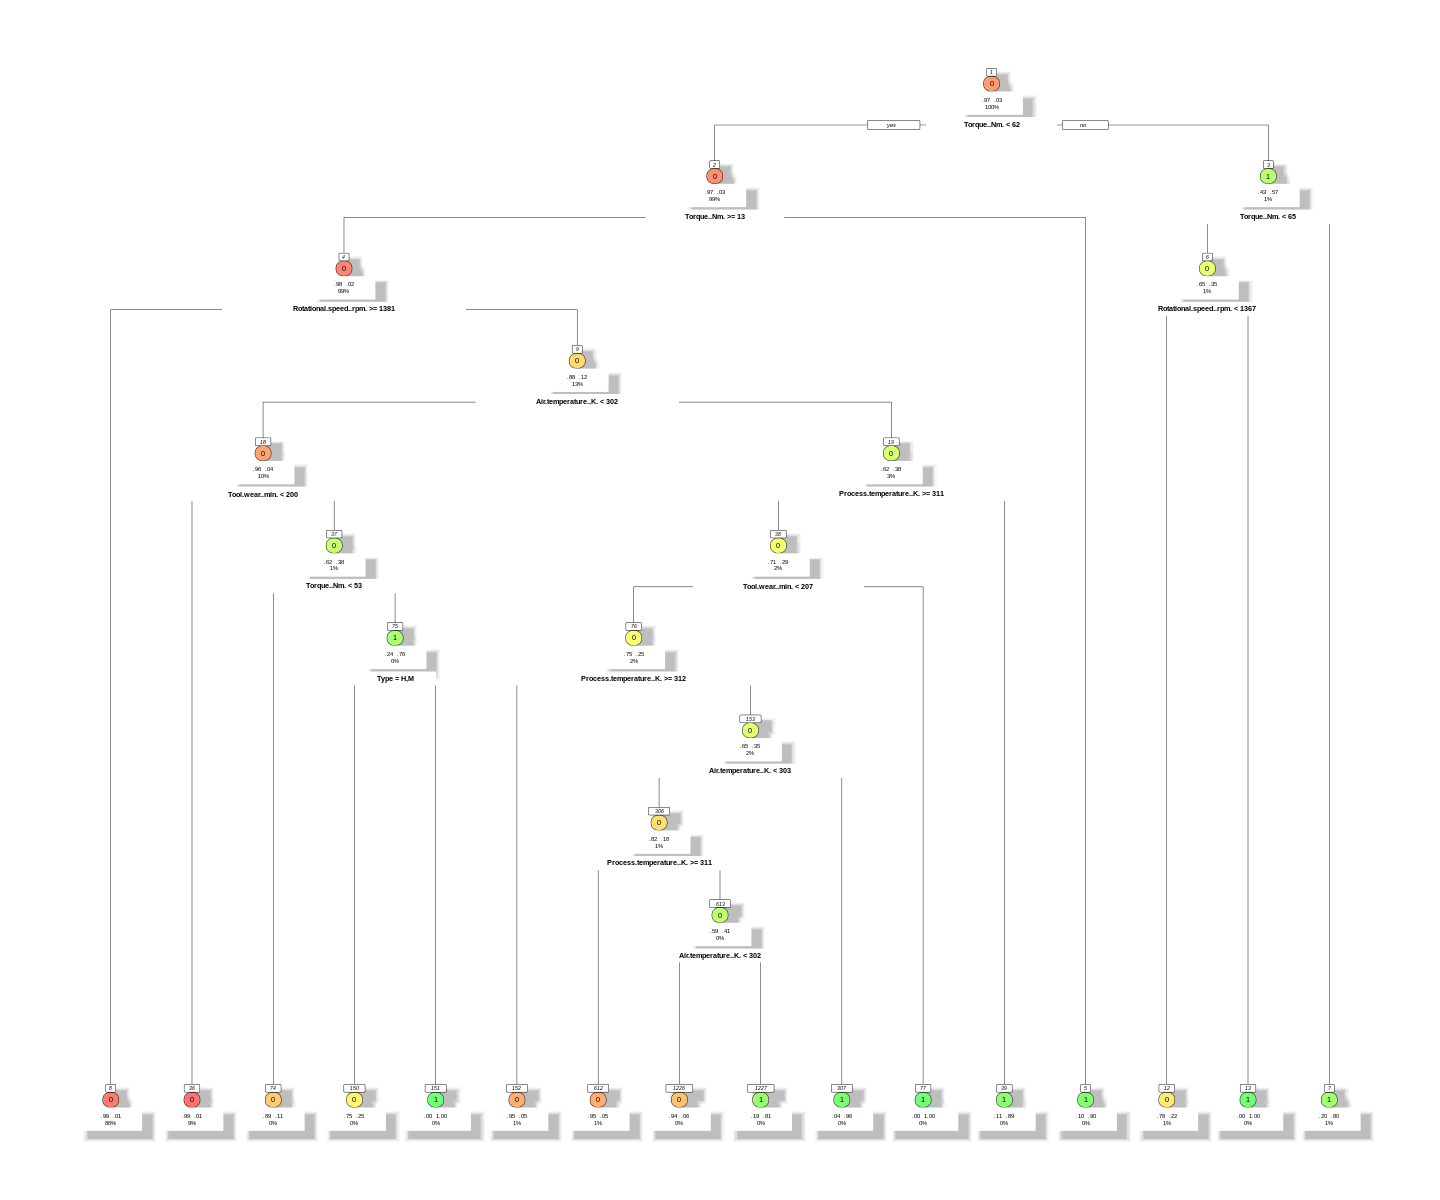

In [33]:
# Plotagem da Árvore de Decisão de forma legível
options(repr.plot.width = 12, repr.plot.height = 10)        # para aumentar a imagem e torná-la mais nítida no Notebook

rpart.plot(
  modelo_arvore,
  type = 2,                                                 # desenha caixas divididas para os nós
  extra = 104,                                              # mostra a porcentagem e a probabilidade de cada classe no nó
  under = TRUE,                                             # coloca os números abaixo dos nós
  box.palette = "RdYlGn",                                   # paleta de cores (Verde para normalidade, Vermelho para falha)
  shadow.col = "gray",                                      # sombra nas caixas para estética
  nn = TRUE                                                 # mostra o número do nó
)

options(repr.plot.width = 7, repr.plot.height = 7)          # apenas para retornar os próximos plots para tamanho padrão comum

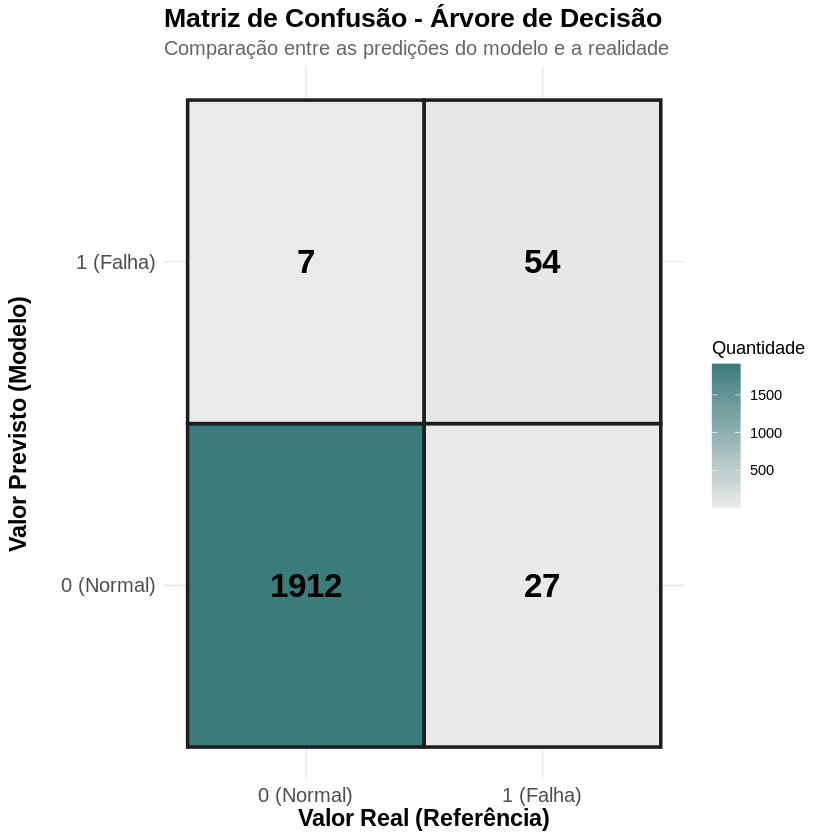

In [34]:
library(ggplot2)

# Fazer as predições usando os dados de teste
predicoes <- predict(modelo_arvore, newdata = dados_teste_limpos, type = "class")

# Gerando a tabela cruzada nativa do R e converter para dataframe
tabela_cm <- table(Prediction = predicoes, Reference = dados_teste_limpos$Machine.failure)
df_cm <- as.data.frame(tabela_cm)

# plotar a Matriz usando ggplot2
ggplot(data = df_cm, aes(x = Reference, y = Prediction, fill = Freq)) +
  geom_tile(color = "#1E1E1E", linewidth = 1) +
  scale_fill_gradient(low = "#EAEAEA", high = "#3A7D7C", name = "Quantidade") +
  geom_text(aes(label = Freq), size = 7, fontface = "bold", color = "black") +
  labs(
    title = "Matriz de Confusão - Árvore de Decisão",
    subtitle = "Comparação entre as predições do modelo e a realidade",
    x = "Valor Real (Referência)",
    y = "Valor Previsto (Modelo)"
  ) +
  scale_x_discrete(labels = c("0" = "0 (Normal)", "1" = "1 (Falha)")) +
  scale_y_discrete(labels = c("0" = "0 (Normal)", "1" = "1 (Falha)")) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 16, face = "bold"),
    plot.subtitle = element_text(size = 12, color = "gray40"),
    axis.title = element_text(size = 14, face = "bold"),
    axis.text = element_text(size = 12)
  )

In [35]:
# Tabela de métricas de desempenho

# Acessando os valores da Matriz de Confusão
VP <- tabela_cm["1", "1"] # Verdadeiro Positivo (54)
VN <- tabela_cm["0", "0"] # Verdadeiro Negativo (1912)
FP <- tabela_cm["1", "0"] # Falso Positivo (7)
FN <- tabela_cm["0", "1"] # Falso Negativo (27)

# Calculo das metricas
acuracia <- (VP + VN) / sum(tabela_cm)
recall   <- VP / (VP + FN)
precisao <- VP / (VP + FP)
f1_score <- 2 * (precisao * recall) / (precisao + recall)

# Dataframe para a tabela
tabela_metricas <- data.frame(
  `Métrica` = c("Acurácia (Acertos Globais)",
                "Recall / Sensibilidade (Captura de Falhas)",
                "Precisão (Confiabilidade do Alarme)",
                "F1-Score (Balanço Harmônico)"),
  `Resultado` = c(
    paste0(round(acuracia * 100, 2), "%"),
    paste0(round(recall * 100, 2), "%"),
    paste0(round(precisao * 100, 2), "%"),
    paste0(round(f1_score * 100, 2), "%")
  ),
  check.names = FALSE
)

# Print da tabela formatada
knitr::kable(
  tabela_metricas,
  align = "lc",
  caption = "Tabela: Métricas de Avaliação da Árvore de Decisão"
)



Table: Tabela: Métricas de Avaliação da Árvore de Decisão

|Métrica                                    | Resultado |
|:------------------------------------------|:---------:|
|Acurácia (Acertos Globais)                 |   98.3%   |
|Recall / Sensibilidade (Captura de Falhas) |  66.67%   |
|Precisão (Confiabilidade do Alarme)        |  88.52%   |
|F1-Score (Balanço Harmônico)               |  76.06%   |

### **5.2. Análise Crítica dos Resultados**

#### **5.2.1. Árvore de Decisão**
A interpretação visual do modelo treinado permite mapear o comportamento do maquinário e as regras operacionais identificadas pelo algoritmo. Desse modo, é possível observar:

* Nó Raiz (Fator Primário): O modelo selecionou o *Torque* como a variável mais discriminante para iniciar a classificação. O algoritmo divide imediatamente os cenários entre operações de torque crítico (maior ou igual a 62 Nm) e torque regular (abaixo de 62 Nm).

* Colapso Direto (Ramos à Direita): Em cenários de força extrema, a quebra mecânica é iminente. A árvore aponta que chegar a um *Torque* de 65 Nm ou superior resulta em falha direta da máquina, sem a necessidade de avaliar outras variáveis.

* Falha por Fadiga Conjunta: Se o equipamento opera em uma faixa crítica de *Torque* (entre 62 e 65 Nm), o modelo analisa a *Velocidade Rotacional*. Caso a rotação caia para menos de 1367 rpm nessas condições, a máquina falha. Isso reflete matematicamente o estresse mecânico severo gerado pela combinação de alta força e baixa velocidade.

* Desgaste e Anomalia Térmica (Ramos à Esquerda): Quando o *Torque* opera em níveis seguros (abaixo de 62 Nm), a probabilidade imediata de sobrecarga cai. Porém, o modelo cria ramificações mais profundas para investigar quebras progressivas, cruzando dados contínuos de *Desgaste da Ferramenta* (Tool.wear.min) com as *Temperaturas do Ar* e do *Processo*. Essa estrutura capta as falhas causadas por fadiga de material a longo prazo ou falhas na dissipação de calor.

#### **5.2.2. Matriz de Confusão**

A Matriz de Confusão aplicada aos dados de teste quantifica o desempenho prático do modelo na distinção entre a operação normal e as anomalias do maquinário:

* Verdadeiros Negativos (1.912 instâncias): O modelo obteve altíssimo êxito em reconhecer o estado de normalidade, garantindo que máquinas saudáveis continuassem operando sem interrupções sistêmicas.

* Verdadeiros Positivos (54 instâncias): O algoritmo identificou corretamente 54 equipamentos que estavam prestes a falhar. Na prática, representam 54 paradas não-programadas (e catastróficas) que foram evitadas com sucesso.

* Falsos Positivos (7 instâncias): Representam os "alarmes falsos", modelo indicou risco de quebra em apenas 7 máquinas que, na realidade, não apresentaram falhas. Operacionalmente, isso representa um custo muito baixo de inspeção técnica desnecessária.

* Falsos Negativos (27 instâncias): Tratam-se das "falhas surpresa", cenários em que ocorreu a quebra do equipamento sem que o modelo emitisse o alerta de risco. Embora seja o principal ponto de atenção para melhorias futuras, a redução desse número em relação ao total de falhas originais já justifica a viabilidade da técnica.

#### **5.2.3. Tabela de Métricas**
A partir da Matriz de Confusão, é possível encontrar os indicadores estatísticos que consolidam a confiabilidade da Árvore de Decisão. Abaixo, avaliamos individualmente cada métrica sob a ótica do problema de negócio (Manutenção Preditiva):

* Acurácia (98.3%): A métrica indica que o modelo acertou a classificação em mais de 98% das vezes. Entretanto, por conta do grande desbalanceamento do problema (a maioria das máquinas operam normalmente), a Acurácia atua apenas como um indicador secundário de estabilidade. Sozinha, ela não reflete a capacidade do modelo de prever as falhas, mas garante que o sistema geral é consistente.

* Recall (66.67%):
Esta é a métrica mais importante. O Recall de quase 67% significa que o modelo conseguiu capturar dois terços de todas as falhas reais que ocorreram no lote de teste. No cenário da Indústria 4.0, antecipar 67% das quebras mecânicas representa uma economia drástica em reposição de peças de emergência e evita perdas milionárias com a linha de produção paralisada.

* Precisão (88.52%):
A Precisão mede a confiabilidade do alerta. O índice de 88,52% garante que, de todas as vezes que o modelo acionou o alarme pedindo manutenção, ele estava correto em quase 9 de cada 10 casos. Uma alta precisão é fundamental para a aceitação do modelo pela equipe de engenharia, pois garante que os técnicos não perderão tempo frequentemente com máquinas que não precisam de reparo (baixíssimo volume de falsos positivos).

* F1-Score (76.06%):
O F1-Score representa a média harmônica entre Recall e Precisão. Alcançar 76% nesta métrica é um resultado sólido para predição de anomalias. Isso prova que a técnica de balanceamento aplicada na etapa de pré-processamento (dados de treino) foi bem-sucedida: ela deu à árvore a capacidade de enxergar as falhas (bom Recall), sem torná-la "paranoica" ao ponto de gerar alarmes para qualquer variação no sensor (alta Precisão).

---


## **Seção 6: Conclusão**

### **6.1. Resumo dos Insights**

A análise estatística e a modelagem preditiva aplicadas ao dados de manutenção industrial permitiram mapear de forma rigorosa o comportamento das variáveis operacionais e compreender padrões subsequentes que formalizam o estudo aplicado.

Respondendo diretamente à pergunta de pesquisa formulada na introdução deste estudo — “É possível prever se uma máquina irá falhar com base nas suas condições operacionais?”

A resposta é afirmativa, os achados empíricos, as validações estatísticas e o desempenho do modelo desenvolvido provam que as falhas de maquinário não ocorrem de forma aleatória: elas estão fortemente ancoradas em comportamentos físicos previsíveis, mensuráveis e computáveis dos equipamentos.

#### **6.1.1. Principais Descobertas** ####

As descobertas fundamentais, organizadas cronologicamente de acordo com o desenvolvimento do relatório, são:

* **Grande desbalanceamento e Assimetria Amostral ([Seção 2.2](#bloco-analise-univariada)):** A análise univariada inicial expôs uma característica que embora condizente a realidade é critica ao domínio do problema: a variável resposta **(`Machine failure`)**, apresenta um severo desbalanceamento entre as classes, no qual apenas $3,4\%$ das instâncias observadas representam falhas reais. Esse diagnóstico inicial mostrou que qualquer modelagem posterior precisaria lidar estatisticamente com esse desbalanceamento para evitar o enviesamento do modelo.

* **Relação Direta entre Torque e Rotação ([Seção 2.3](#bloco-analise-bivariada)):** A análise bivariada revelou uma forte correlação linear negativa ($\approx -0,88$) entre Torque (Nm) e Velocidade Rotacional (rpm), um reflexo fidedigno com a realidade considerando a potência de maquinas operantes. O mapeamento conjunto evidenciou que as falhas se concentram em zonas de estresse mecânico bem delimitadas.

* **Correlação entre Temperatura Ambiente e do Processo ([Seção 2.3](#bloco-analise-bivariada)):** A temperatura do ambiente (Air Temperature) e a temperatura interna da máquina (Process Temperature) andam praticamente juntas, com uma correlação de $\approx 0,98$. O verdadeiro gatilho para a máquina quebrar por superaquecimento (HDF) é a Diferença de Temperatura ($\Delta T$) entre o ambiente e o processo, e não os valores isolados.

* **Desgaste da Ferramenta como Preditor de Fadiga ([Seção 3](#bloco-validacao-estatistica)):** Através do teste não paramétrico de Mann Whitney aplicado à variável Tool Wear (min), rejeitou a hipótese nula  $\mu_{0}$ com um p-valor virtualmente nulo ($p < 2.2 \times 10^{-16}$). Sob um nível de confiança superior a 95%, é provado matematicamente que a distribuição de postos do desgaste é maior no grupo de máquinas que falharam. Isso consolida o desgaste acumulado da ferramenta como um indicador altamente confiável para prever quebras por fadiga de material (Tool Wear Failure - TWF).

* **Eficácia do Pré-processamento e Balanceamento ([Seção 4](#bloco-pre-processamento)):** A aplicação de técnicas de balanceamento e a seleção de features foram indipensáveis para o andamento do estudo. Essas etapas mitigaram o severo viés provocado pelo desbalanceamento constatado na EDA, permitindo que o algoritmo aprendesse os padrões de maneira geral invés de simplesmente memorizar a classe majoritária.

* **Ótima performance e Capacidade de Decisão do Modelo ([Seção 5](#bloco-resultados)):** A avaliação do classificador pelo algoritmo de Árvore de Decisão confirmou a viabilidade na prática da manutenção preditiva. A análise da **Matriz de Confusão** e das **Métricas de Desempenho** (como o Recall e F1-Score) demonstrou que o modelo possui alta sensibilidade para antecipar falhas antes que elas causem paradas problemáticas, mantendo um índice controlado de falsos alarmes (falsos positivos). As regras de divisão da árvore mostraram matematicamente que o Torque, a Velocidade e o Desgaste são ,realmente, as variáveis com maior ganho de informação para a tomada de decisão.


### **6.2. Recomendações Práticas**

Com base nos diagnósticos estatísticos e no comportamento preditivo identificados ao longo deste projeto, seguem duas ações concretas para otimização e mitigação de custos operacionais com paradas não planejadas:

#### **6.2.1. Implementação de um Gatilho Preditivo para Troca de Ferramenta**

* **Ação Concreta:** Substituir a possível política de manutenção preventiva baseada em cronogramas fixos por uma política preditiva baseada no tempo acumulado de operação do componente. O sistema de monitoramento deve disparar um **Alerta de Aviso** automático ao atingir uma marca próxima a de **130 minutos** de uso efetivo da ferramenta e um **Alerta de Ordem de Manutenção** ao atingir a marca limite de **150 minutos** para a substituição preventiva.

* **Justificativa Estatística:** O teste não paramétrico de Mann Whitney provou de forma matemática que o risco de quebra por fadiga de material (TWF) se acentua drásticamente após a marca de **150 minutos**. Estabelecer o corte em **150 minutos** protege antes do ponto crítico de colapso.

#### **6.2.2. Intervenção Humana para Mitigação de Falsos Negativos**

* **Ação Concreta:** Instituir uma rotina de inspeção técnica secundária por amostragem visual em máquinas que o algoritmo classificou como "estáveis" (classe 0), mas que estejam operando em regimes de limite (acima de **130 minutos** de desgaste ou próximos a **60 Nm** de torque por exemplo).

* **Justificativa por Métricas:** A análise da **Matriz de Confusão** revelou que o modelo gerou **27 Falsos Negativos** no teste. No contexto industrial, esse é o erro mais custoso, pois representa uma falha problemática não detectada pelo sistema. Como o Recall do modelo foi de $66.67\%$, essa camada operacional humana atuará cobrindo os $33.33\%$ de falhas que escaparam do algoritmo, protegendo a linha de produção contra paradas inesperadas.

### **6.3. Limitações e Próximos Passos**

Embora o modelo da Árvore de Decisão e as validações estatísticas tenham apresentado resultados altamente satisfatórios para o domínio do problema, o estudo possui suas limitações. É fundamental reconhecer as restrições deste projeto para produzir boas investigações futuras:

#### **6.3.1. Limitações do Estudo**

* **Acentuado Desbalanceamento Amostral:** Embora o percentual de $3.4\%$ de falhas seja um reflexo fiel e esperado da realidade de uma planta industrial saudável (onde as máquinas operam em normalidade na maior parte do tempo), essa assimetria impôe um severo desafio matemático para o treinamento de algoritmos. Os modelos preditivos expostos a tais situações tendem a ignorar a classe minoritária (nesse caso falha) para maximizar a acurácia global na classe majoritária.

* **Indisponibilidade do Histórico Temporal Contínuo:** O conjunto de dados apresenta medições agregadas por instâncias estáticas, impedindo a análise de séries temporais. Na realidade de uma planta industrial, as variáveis de sensores se comportam de forma dinâmica e contínua, onde a tendência de elevação de uma temperatura ou a taxa de variação do torque ao longo do tempo fornecem mais informações do que um registro pontual isolado.

* **Redundância e Multicolinearidade:** Devido à colinearidade quase perfeita encontrada na EDA entre as temperaturas do ar e do processo ($\approx 0,98$), o modelo teve que trabalhar com atributos redundantes na seleção de features, tal fato, compromete a interpretação direta da importância real de cada sensor individualmente.

#### **6.3.2. Próximos Passos**

* **Aprimoramento dos Atributos:** Implementar a criação da variável correspondente à diferença de temperatura  $\Delta T = \text{Temperatura do Processo} - \text{Temperatura do Ar}$ para isolar o efeito da dissipação do calor em uma única dimensão contínua, reduzindo a dimensionalidade do modelo sem perca de informação relevante.

* **Exploração de Multiclassificadores:** Substituir a árvore de decisão simples por algorítmos baseados em conjunto de árvores (como Random Forest ou XGBoost) para elevar a métrica **Recall** para acima dos $66.67\%$ obtidos, que em conjunto com a proposta manual de intervenção humana irá diminuir ainda mais os índices de falsos negativos.

* **Modelagem Multiclasse:** Expandir o escopo do classificar binário (Machine failure) para uma abordagem de classificação multiclasse que utilize as subcausas removidas (TWF, HDF, PWF, OSF) como alvos específicos. Isso permitirá que o sistema não apenas preveja qual máquina irá falhar, mas diagnostique com precisão qual componente físico causou a falha.

